# Load the data and split it

In [1]:
import get_data as data
import matplotlib.pyplot as plt
from keras import layers, models
import tensorflow as tf

image_size = (64, 64)

(train_images, test_images) = data.get_data(image_size)

print("Number of training batches: ", len(train_images))
print("Number of testing batches: ", len(test_images))

Found 75000 files belonging to 5 classes.
Using 52500 files for training.
Using 22500 files for validation.
Number of training batches:  1641
Number of testing batches:  704


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

In [2]:
class_names = train_images.class_names
print(class_names)

['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


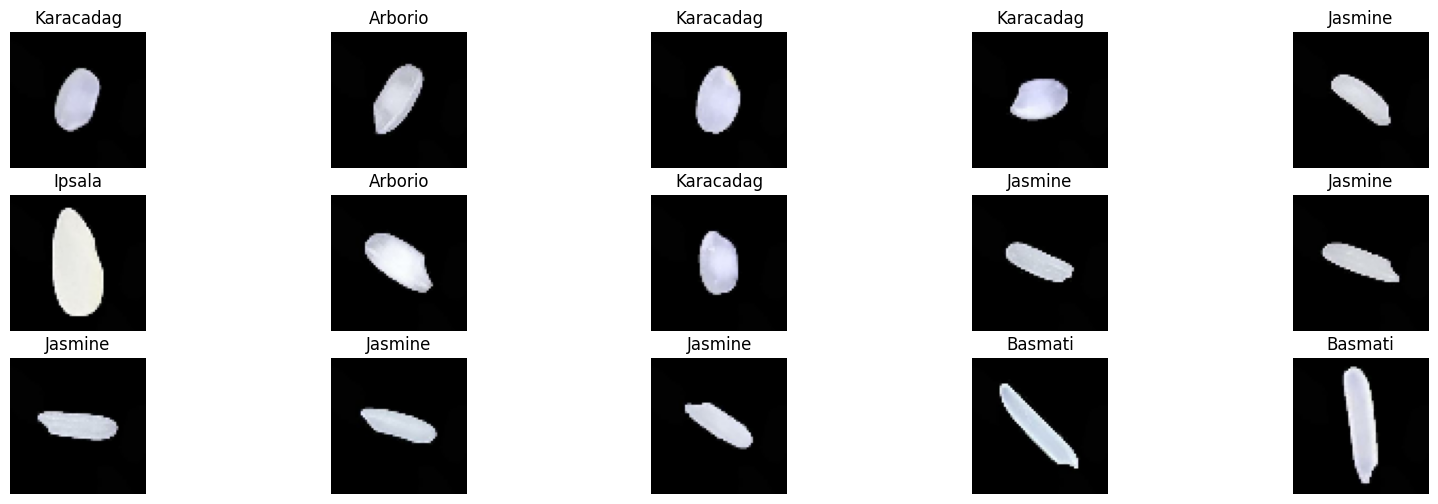

In [3]:
plt.figure(figsize=(20,6))

for images, labels in train_images.take(1):
    for i in range(15):
        plt.subplot(3,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [4]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(8, (3,3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,973 (7.71 KB)

 Trainable params: 1,973 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [7]:
model.fit(train_images, epochs=10, validation_data=test_images)

Epoch 1/10
1113/1641 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5131 - loss: 14.1034

KeyboardInterrupt: 